# Signal to Noise Ratio (SNR) for ASCON leakage model

### Configuration

In [25]:
import sys
sys.path.append( '../../../sca_scripts' )
from analyzer.attack.ascon.xheep_ascon_cpa.ascon_first_round import ascon_first_round

from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import h5py
import logging

# ensure logging prints in Jupyter
logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s - %(levelname)s - %(message)s",
                    force=True)


In [26]:
key = "000102030405060708090A0B0C0D0E0F"
IV = "00001000808C0001" # Computed from the ASCON 128A parameters
IV = int(IV, 16)

# Number of traces
N = 10000
# Supported S-box types:
# lut_ascon, lut_bilgin, lut_allouzi, lut_lu_4, lut_lu_5, lut_lu_6, lut_lu_7
sbox_type = "lut_ascon"

traces_file = r"/traceset/ascon_sw/ascon_opt32_" + sbox_type + "_" + str(N//1000) + "k.h5"

Notebook configurations :

| Parameter | Meaning |
|---|---|
| `snr_all_bits` | Set True to compute SNR for all 64 bits (default: False). |
| `snr_single_bit` | Set True to compute SNR for a single bit (use `bit_index`). |
| `target_bit` | Index of the bit to analyze (0–63). |
| `target_register` | Target register: 0 = S0, 1 = S1. |
| `debug` | Set True to enable debug/verbose prints. |

In [27]:
snr_all_bits = False  # Set to True to compute SNR for all bits
snr_single_bit = True  # Set to True to compute SNR for a single bit only
target_bit = 49
target_register = 0 # 0 or 1
debug = False   # Set to True to enable debug prints

# log the SNR configuration (place this cell after the configuration variables are set)
logging.info("SNR configuration - snr_all_bits=%s, snr_single_bit=%s, target_bit=%d, target_register=%d, debug=%s",
             snr_all_bits, snr_single_bit, target_bit, target_register, debug)

2025-11-10 16:10:13,396 - INFO - SNR configuration - snr_all_bits=False, snr_single_bit=True, target_bit=49, target_register=0, debug=False


In [28]:
shift_amount = [19, 28] if target_register == 0 else [61, 39]

# Reverse the key bytes to match X-HEEP's endianness
key_bytes = [key[i:i+2] for i in range(0,len(key), 2)]
key_reversed = ''.join(key_bytes[::-1])
key = int(key_reversed, 16)

## Computing the SNR 

### Utility functions

In [29]:
# Utility functions
def prepare_data(trace_set, labels_set):
    """
    trace_set = a set of traces
    labels_set = the leakage model of the target intermediate value
    
    returns a dictionary of the form
       'label_value': list of traces associated with 'label_value'
    """
   
    labels=np.unique(labels_set)
    # Initialize the dictionary
    d={}
    for i in labels:
         d[i]=[]
    for count, label in enumerate(labels_set):
        d[label].append(trace_set[count])
    return d

def return_snr_trace(trace_set, labels_set):
    """
    trace_set = a set of traces
    labels_set = a set of labels of the same lenght as trace_set

    returns a dictionary of the form
       'label_value': mean_sample trace with 'label_value'
    """
    mean_trace={}
    signal_trace=[]
    noise_trace=[]
    # Determine the set of unique values for the leakage model. In this case,
    # the leakage model is the attacked bit, so the labels = {0,1}.
    labels=np.unique(labels_set)
    # Group the traces according to the label
    grouped_traces=prepare_data(trace_set, labels_set)
    # Compute the mean trace (the same are the signal traces)
    for i in labels:
        mean_trace[i]=np.mean(grouped_traces[i], axis=0)
        signal_trace.append(mean_trace[i])
    # Compute the noise trace
    for i in labels:
        for trace in grouped_traces[i]:
            noise_trace.append(trace-mean_trace[i])
    var_noise=np.var(noise_trace, axis=0)
    var_signal=np.var(signal_trace, axis=0)
    snr_trace=var_signal/var_noise
    return snr_trace

### SNR for each bit if set `snr_all_bits`

In [30]:
snr_all_bits_computed = False
if (snr_all_bits):
    # This list contains the maximum SNR value for each attacked bit
    max_SNR_values = []
    try:
        with h5py.File(traces_file, 'r') as f_read_traces:
            traces = f_read_traces['traces'][:N]
            nonces = f_read_traces['nonces'][:N]

            # DEBUG
            print(f"Number of traces analyzed: {len(traces)}, each composed of samples: {len(traces[0])}")

            for bit_i in tqdm(range(0, 64), desc="Attacking bits"):
                # Divide the traces according to the target bit value of the 
                # output register S0 or S1 at the end of the linear diffusion layer.
                label_attacked_bit=[]
                for i in range(0, len(traces)):
                    # Reconstruct the nonce from the two halves
                    nonce = int(nonces[i][0]) << 64 | int(nonces[i][1])
                    # Compute the expected value of the state at the end of the first round
                    S = ascon_first_round(key, nonce, sbox_type)
                    # if 0 <= i < 2:
                    #     print(f"Nonce: {nonce:016X}, S[0]: {S[0]:016X}")
                    # Extract the bit of interest from the state register S0 and divide the traces
                    # according to its value.
                    if target_register == 0:
                        label_attacked_bit.append((S[0] >> bit_i) & 0x01)
                    else:
                        label_attacked_bit.append((S[1] >> bit_i) & 0x01)

                snr_trace_attacked_bit = return_snr_trace(traces, label_attacked_bit)

                # Save the maximum SNR value for each bit
                max_snr_value = np.max(snr_trace_attacked_bit)
                max_SNR_values.append(max_snr_value)

            if debug:
                # Print the list of maximum SNRs
                print("Maximum SNR values for each attacked bit:")
                for i, max_snr in enumerate(max_SNR_values):
                    print(f"Bit {i + target_register*64}: {max_snr}")

            # Transform the list of max SNR values into python dictionary where the key is 
            # the bit index and the value is the max_SNR[bit_index]
            max_snr_dict = {i: max_SNR_values[i] for i in range(len(max_SNR_values))}

            # Sort dictionary keys by correlation value (highest to lowest)
            sorted_keys = sorted(max_snr_dict, key=lambda k: max_snr_dict[k], reverse=True)

            bits_to_attack = []
            covered_bits = set()

            for index in sorted_keys:
                bits = {index % 64, (index + shift_amount[0]) % 64, (index + shift_amount[1]) % 64}
                if bits - covered_bits:  # at least one new bit
                    bits_to_attack.append(index)
                    covered_bits.update(bits)
                if len(covered_bits) == 64:  # all bits covered
                    snr_all_bits_computed = True
                    break

            print(f"Bits ordered in increasing value of SNR:\n {bits_to_attack}")

    except FileNotFoundError:
        print(f"ERROR: Traces file {traces_file} not found.")


In [31]:
if (snr_all_bits_computed):
    index_snr_max = np.argmax(max_SNR_values)
    print(f"Index of maximum SNR value: {index_snr_max}, Maximum SNR value: {max_SNR_values[index_snr_max]}")
    index_snr_min = np.argmin(max_SNR_values)
    print(f"Index of minimum SNR value: {index_snr_min}, Minimum SNR value: {max_SNR_values[index_snr_min]}")
    index_snr_avg = 49
    print(f"Index of average SNR value: {index_snr_avg}, Average SNR value: {max_SNR_values[index_snr_avg]}")

## SNR of single bit

In [32]:
if (snr_single_bit):
    try:
        with h5py.File(traces_file, 'r') as f_read_traces:
            traces = f_read_traces['traces'][:N]
            nonces = f_read_traces['nonces'][:N]

            # DEBUG
            print(f"Number of traces: {len(traces)}, Number of samples: {len(traces[0])}")

            # Divide the traces according to the target bit value of the 
            # output register S0 or S1 at the end of the linear diffusion layer.
            label_attacked_bit=[]
            for i in range(0, len(traces)):
                # Reconstruct the nonce from the two halves
                nonce = int(nonces[i][0]) << 64 | int(nonces[i][1])
                # Compute the expected value of the state at the end of the first round
                S = ascon_first_round(key, nonce, sbox_type)
                # if 0 <= i < 2:
                #     print(f"Nonce: {nonce:016X}, S[0]: {S[0]:016X}")
                # Extract the bit of interest from the state register S0 and divide the traces

                # according to its value.
                if target_register == 0:
                    label_attacked_bit.append((S[0] >> target_bit) & 0x01)
                else:
                    label_attacked_bit.append((S[1] >> target_bit) & 0x01)

            snr_trace_attacked_bit = return_snr_trace(traces, label_attacked_bit)

    except FileNotFoundError:
        print(f"ERROR: Traces file {traces_file} not found.")


Number of traces: 10000, Number of samples: 1125


## Plot for the target bit the _SNR vs Sample_ 

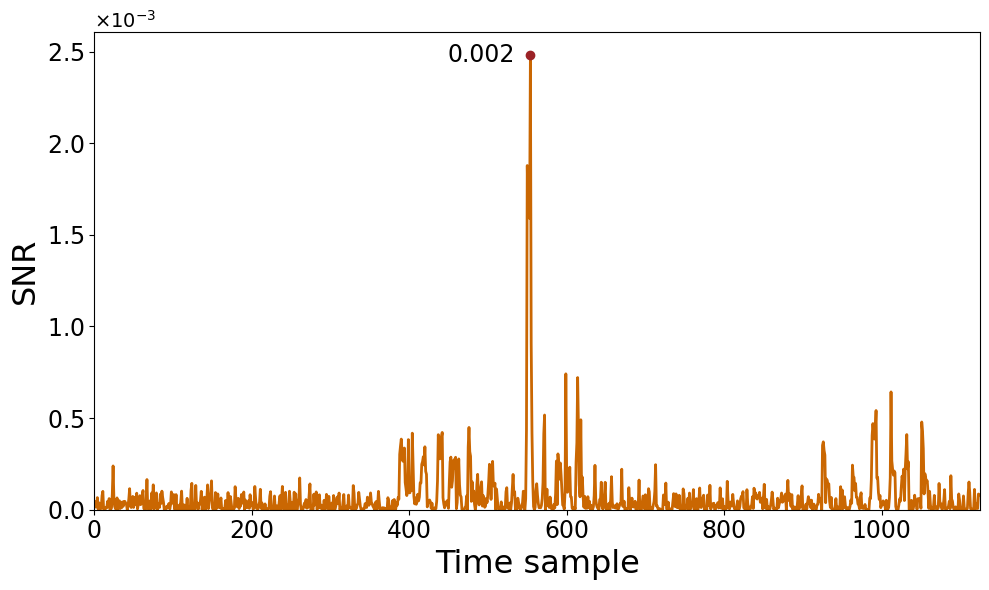

In [33]:
fig, ax = plt.subplots(figsize=(10, 6))
snr = np.asarray(snr_trace_attacked_bit)
x = np.arange(len(snr))

ax.plot(x, snr, color='#ca6702', linewidth=2)

# find max and annotate (no arrow, text moved left)
imax = int(np.argmax(snr))
vmax = float(snr[imax])
ax.plot(imax, vmax, 'o', color='#9b2226', markersize=6)
ax.annotate(f"{vmax:.3f}",
            xy=(imax, vmax),
            xytext=(imax - 20, vmax),
            textcoords='data',
            ha='right',
            va='center',
            color='black',
            fontsize=17)


ax.tick_params(axis='y', labelcolor='black', labelsize=17)
ax.tick_params(axis='x', labelsize=17)
# force scientific notation when values are ~1e-3 or smaller (shows "×10⁻³" offset)
fmt = ScalarFormatter(useMathText=True)
fmt.set_powerlimits((-3, 0))   # switch to scientific for exponents <= -3
ax.yaxis.set_major_formatter(fmt)
ax.yaxis.get_offset_text().set_fontsize(14)  # adjust offset font size if needed

# set x limit from 0 to len(x) and y to start from 0
ax.set_xlim(0, len(x))
ax.set_ylim(bottom=0)
#ax.set_title(f"SNR trace for bit {target_bit + target_register*64} of reg X0")
ax.set_xlabel('Time sample', fontsize=23)
ax.set_ylabel('SNR', fontsize=23)
ax.grid(False)
plt.tight_layout()
plt.savefig("graphs/ASCON_SNR_bit_" + str(target_bit + target_register*64) + ".pdf")
plt.show()
plt.close()